# Classificação Supervisionada com KMeans no Dataset Adult (Balanceado)

Este notebook aplica o balanceamento das classes do dataset Adult por oversampling da classe minoritária antes do treinamento do KMeans supervisionado. O objetivo é comparar o desempenho do agrupamento com e sem desbalanceamento.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.cluster import KMeans
import os
import seaborn as sns
os.makedirs('img', exist_ok=True)

## 1. Carregamento e Balanceamento dos Dados

In [2]:
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)
adult_df = adult_df_raw.dropna().copy()
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=n_majority,
    random_state=42
)
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


## 2. Pré-processamento dos Dados

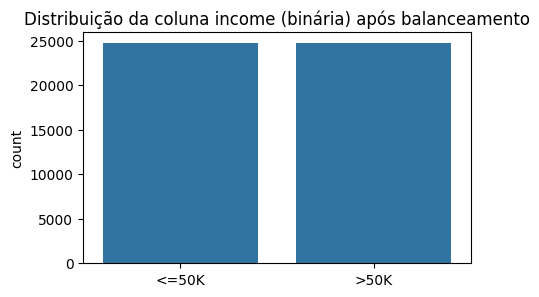

In [3]:
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
y = adult_df_balanced['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária) após balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [5]:
n_clusters = 2

In [6]:
class KMeansSupervisionado:
    def __init__(self, n_clusters=2, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

Acurácia: 0.5346
Matriz de Confusão:
[[7204  212]
 [6691  725]]


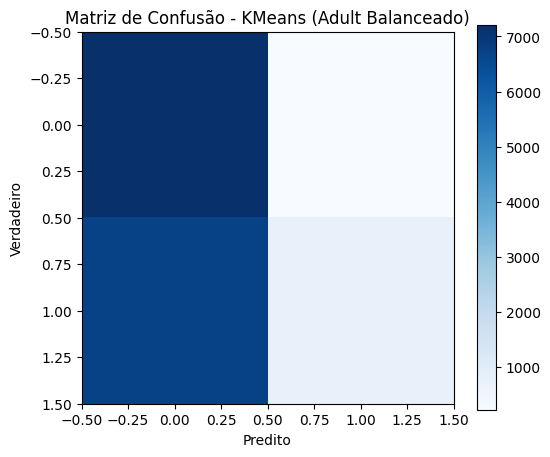

In [7]:
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - KMeans (Adult Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/kmeans_adult_balance_confusion_matrix.png')
plt.show()

Acurácia média: 0.6671
Desvio padrão da acurácia: 0.0554
MSE médio: 0.3329
Desvio padrão do MSE: 0.0554


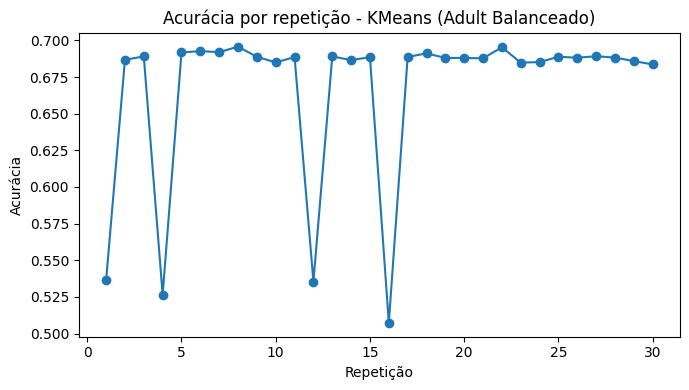

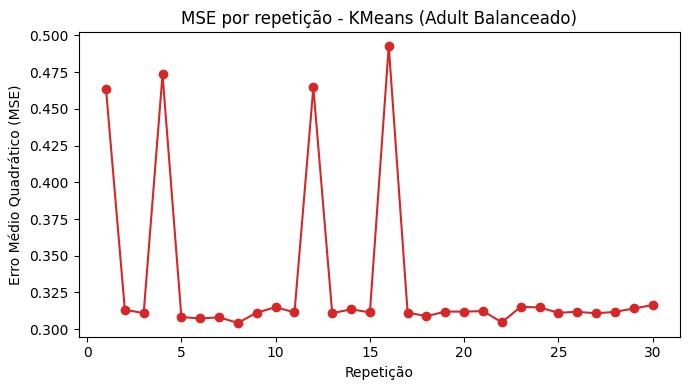

In [8]:
acuracias = []
mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)
acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
plt.figure(figsize=(7,4))
plt.plot(range(1, 31), acuracias, marker='o', color='tab:blue')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig('img/kmeans_adult_balance_accuracy_repetitions.png')
plt.show()
plt.figure(figsize=(7,4))
plt.plot(range(1, 31), mse_array, marker='o', color='tab:red')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig('img/kmeans_adult_balance_mse_repetitions.png')
plt.show()
np.save('img/kmeans_adult_balance_accuracies.npy', acuracias)
np.savetxt('img/kmeans_adult_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/kmeans_adult_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/kmeans_adult_balance_mse_repetitions.csv', mse_array, delimiter=',')

## Análise dos Resultados

Compare os resultados obtidos com o dataset balanceado e o original. Observe se houve melhora na matriz de confusão, acurácia média e estabilidade do método.